# Intro to EmberFlow
---

In this notebook, we show age predictions for M dwarfs using rotation period and stellar mass.

EmberFlow learns $p(\log P_{\mathrm{rot}} \mid \log\tau,\, M_\star,\, \sigma_M)$, which returns a full age posterior instead of a point estimate.
Below, we use mock data to demonstrate how to perform inference using the model.



In [1]:
import matplotlib.pyplot as plt
import numpy as np

from emberflow import EmberFlow, flat_in_age
from emberflow.plots import (COLOR, COLOR_ACCENT, FIG_SINGLE, FIG_WIDE,
                             LABEL_FS, TICK_FS, set_age_axis, set_paper_style)

set_paper_style()

ef = EmberFlow.load()
ef.card["n_train"], ef.card["cond_cols"]

(6584, ['log_age_myr', 'mass_msun', 'mass_msun_err_avg'])

## A single star

The cell below shows the summary for the posterior distribution for this star.

In [2]:
post = ef.age_posterior(prot=20.0, mass=0.55, mass_err=0.02)

print(post)
print(f"median  {post.median_gyr:.2f} Gyr")
print(f"mode    {post.mode_gyr:.2f} Gyr")
print(f"68%     {post.interval(0.68)[0]:.2f} - {post.interval(0.68)[1]:.2f} Gyr")
print(f"95%     {post.interval(0.95)[0]:.2f} - {post.interval(0.95)[1]:.2f} Gyr")

AgePosterior(1.77 -0.64/+1.04 Gyr, 68%)
median  1.77 Gyr
mode    1.79 Gyr
68%     1.13 - 2.81 Gyr
95%     0.51 - 6.01 Gyr


We can also examine the full age posterior.

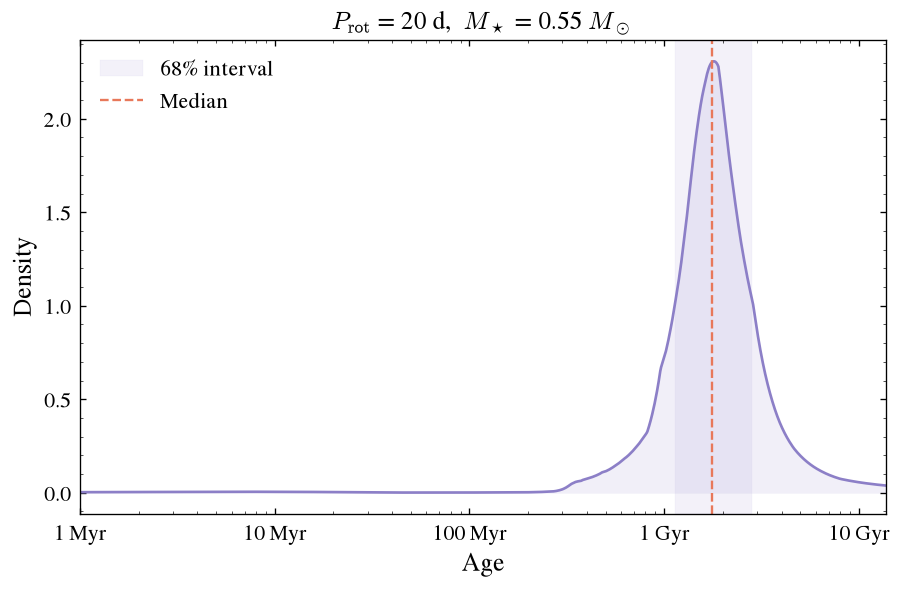

In [3]:
fig, ax = plt.subplots(figsize=FIG_SINGLE, layout="constrained")
lo, hi = post.interval(0.68)

ax.plot(post.age_gyr_grid, post.pdf, color=COLOR, lw=1.6)
ax.fill_between(post.age_gyr_grid, post.pdf, color=COLOR, alpha=0.12)
ax.axvspan(lo, hi, color=COLOR, alpha=0.10, label="68% interval")
ax.axvline(post.median_gyr, color=COLOR_ACCENT, ls="--", lw=1.4, label="Median")

ax.set_xscale("log")
ax.set_xlim(1e-3, 13.8)
set_age_axis(ax)
ax.set_ylabel("Density", fontsize=LABEL_FS)
ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.set_title(r"$P_{\rm rot}$ = 20 d,  $M_\star$ = 0.55 $M_\odot$", fontsize=LABEL_FS)
ax.legend(frameon=False, fontsize=TICK_FS)

## Priors

The default prior used is uniform in log age. Custom priors can be substituted to see how they influence model predictions.

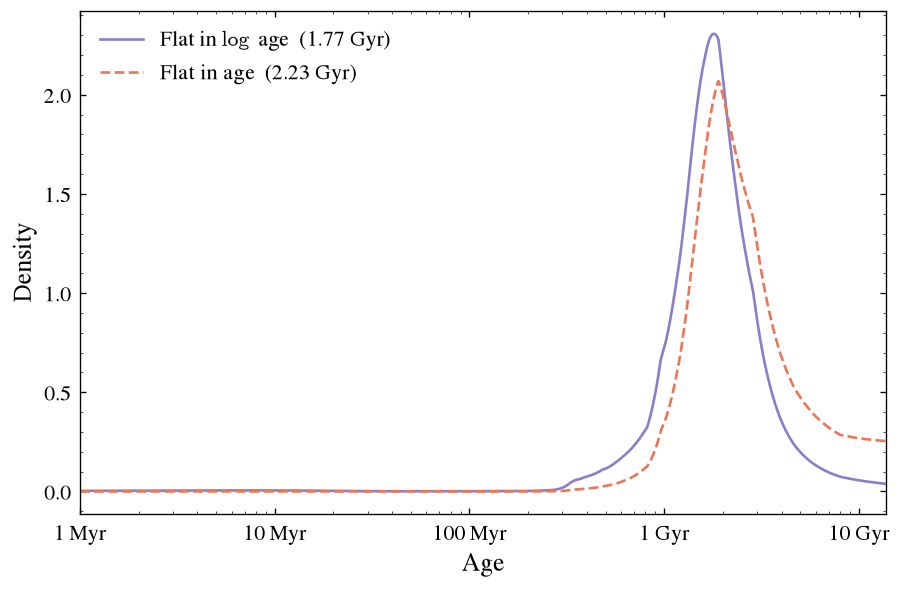

In [4]:
p_log = ef.age_posterior(prot=20.0, mass=0.55, mass_err=0.02)
p_lin = ef.age_posterior(prot=20.0, mass=0.55, mass_err=0.02, prior=flat_in_age)

fig, ax = plt.subplots(figsize=FIG_SINGLE, layout="constrained")

ax.plot(p_log.age_gyr_grid, p_log.pdf, color=COLOR, lw=1.6,
        label=rf"Flat in $\log$ age  ({p_log.median_gyr:.2f} Gyr)")
ax.plot(p_lin.age_gyr_grid, p_lin.pdf, color=COLOR_ACCENT, lw=1.6, ls="--",
        label=rf"Flat in age  ({p_lin.median_gyr:.2f} Gyr)")

ax.set_xscale("log")
ax.set_xlim(1e-3, 13.8)
set_age_axis(ax)
ax.set_ylabel("Density", fontsize=LABEL_FS)
ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.legend(frameon=False, fontsize=TICK_FS, loc="upper left")

## Training range

Note that stars with a mass outside of the supported training range receive a warning (0.08 to 0.70 solar masses). However, the flow can still extrapolate predictions for such stars.

In [5]:
print(ef.card["training_range"])

ef.age_posterior(prot=20.0, mass=0.95, mass_err=0.02);

{'mass_msun': [0.0980828133327475, 0.6738609822056498], 'prot_days': [0.0824, 174.4], 'age_gyr': [0.0015, 11.5]}


C:\Users\caram\projects\cf\emberflow\src\emberflow\model.py:95: UserWarning: 1 star(s) outside the training range of mass_msun [0.0981, 0.674]; ages there are extrapolated and should not be trusted.
  lp = self._grid_log_probs(prot, mass, mass_err, loga_grid)
